In [1]:
!pip install lifelines 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import shap 
import warnings 
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split , RandomizedSearchCV 
from sklearn.preprocessing import LabelEncoder , StandardScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from sklearn.metrics import (classification_report,confusion_matrix,ConfusionMatrixDisplay,roc_auc_score,roc_curve)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from collections import Counter
import textwrap

TITLE = "#EF6D09DE"
VALUE = "#565A5B"
LABEL = "#565A5B"
BAR   = ["#DB5F00","#E6EEE5","#0B6D72","#E7EA07","#519503"]
pd.set_option('display.max_columns', None)
plt.rcParams.update({
    'font.size': 14, 'font.weight': 'bold',
    'axes.labelweight': 'bold', 'axes.titleweight': 'bold',
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'figure.facecolor': "#000000", 'axes.facecolor': "#000000",
    'axes.edgecolor': LABEL, 'axes.labelcolor': LABEL,
    'xtick.color': VALUE, 'ytick.color': VALUE,
    'text.color': LABEL, 'axes.titlecolor': TITLE,
    'axes.grid': False,
})
print("✅ Libraries Loaded Successfully")




  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=8b01aab9d0e72a5a94eb07f44b982a54ed39627521190423e94de4e95330923b
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
✅ Libraries Loaded Successfully


In [2]:
df=pd.read_csv('/kaggle/input/datasets/kvsherlin/hr-analysis/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.drop(columns=['EmployeeCount','EmployeeNumber','StandardHours','Over18'],inplace=True,errors='ignore')

df['Attrition'] = df['Attrition'].map({'Yes':1,'No':0})
df['OverTime'] = df['OverTime'].map({'Yes':1,'No':0})

print(f"✅ Dataset loaded  | Shape: {df.shape}")
print(f"   Attrition Rate : {df['Attrition'].mean()*100:.1f}%")
print(df['Attrition'].value_counts())
print(df.dtypes)





✅ Dataset loaded  | Shape: (1470, 31)
   Attrition Rate : 16.1%
Attrition
0    1233
1     237
Name: count, dtype: int64
Age                          int64
Attrition                    int64
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
OverTime                     int64
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StockOptionLevel             int64
TotalWorkingYears            int64
Train

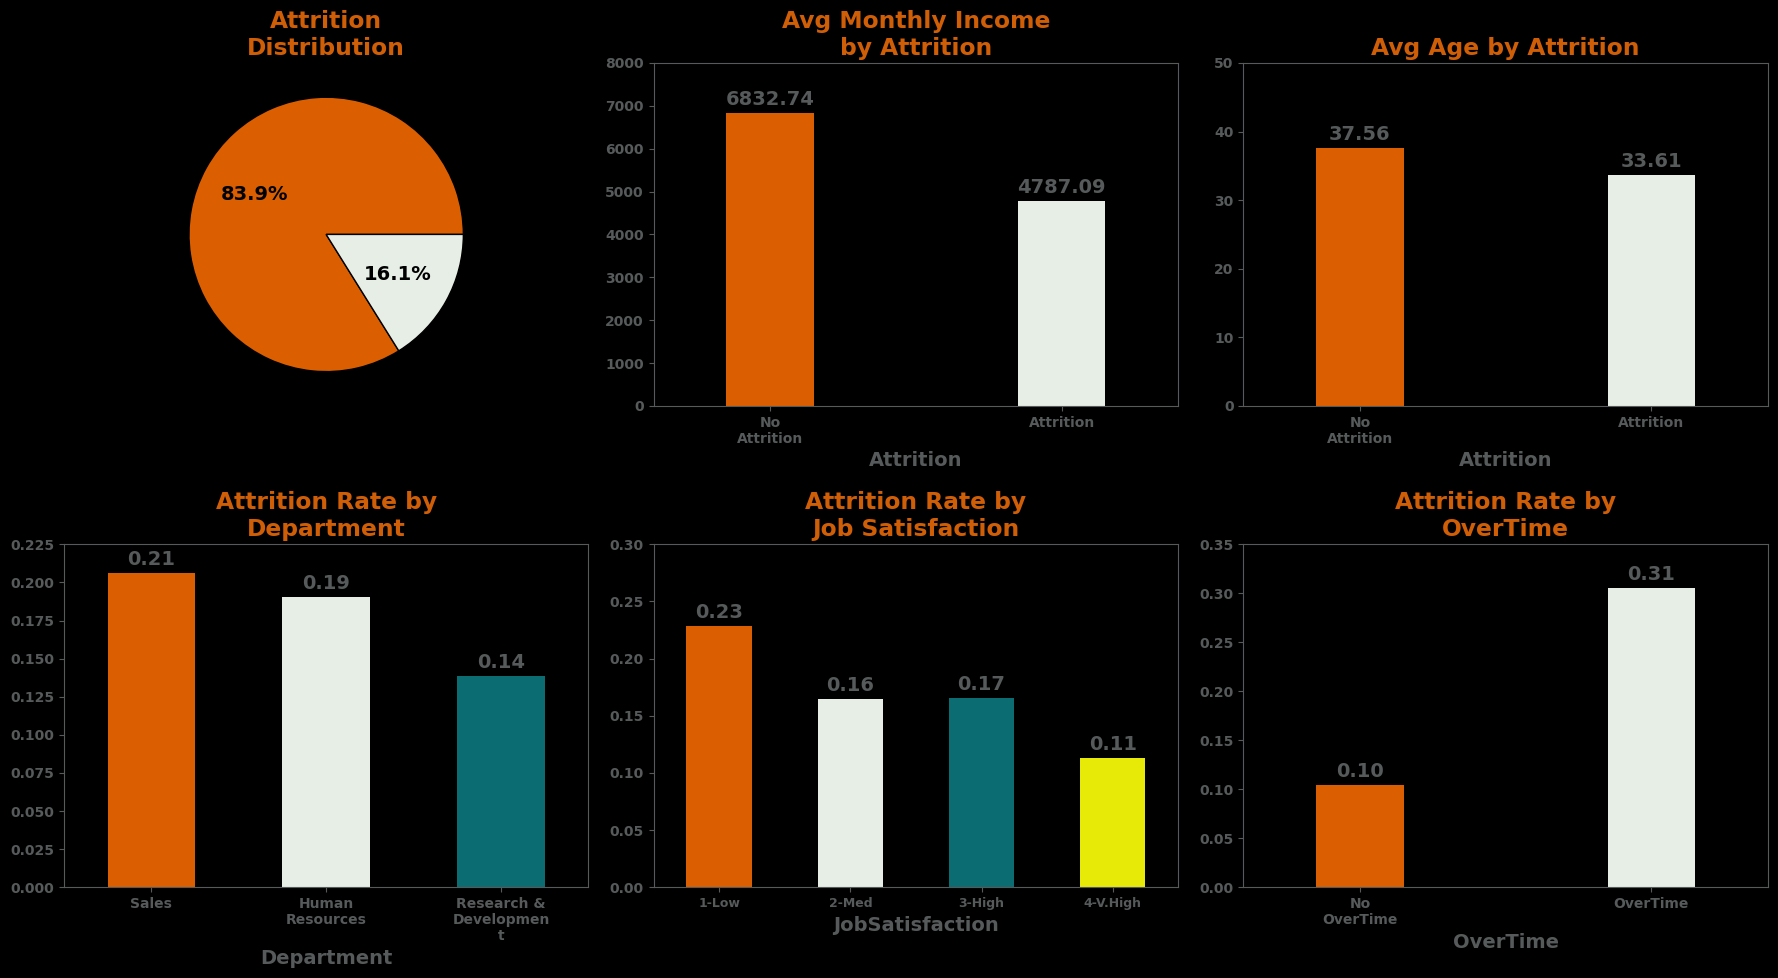

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
ax=axes.ravel()
# Attrition Distribution
df['Attrition'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[0,0],
    colors=BAR, labels=['No Attrition','Attrition'],
    textprops={'color':'#000000','fontweight':'bold'},
    wedgeprops={'edgecolor':'black'})
axes[0,0].set_title('Attrition Distribution', fontweight='bold')
axes[0,0].set_ylabel('')


# Avg Monthly Income by Attrition
df.groupby('Attrition')['MonthlyIncome'].mean().plot(
    kind='bar', color=BAR, ax=axes[0,1], width=0.3)
axes[0,1].set_title('Avg Monthly Income by Attrition', fontweight='bold')
axes[0,1].set_xticklabels(['No Attrition','Attrition'], rotation=0, fontweight='bold')
axes[0,1].set_ylim(0,8000)

# Avg Age by Attrition
df.groupby('Attrition')['Age'].mean().plot(
    kind='bar', color=BAR, ax=axes[0,2], width=0.3)
axes[0,2].set_title('Avg Age by Attrition', fontweight='bold')
axes[0,2].set_xticklabels(['No Attrition','Attrition'], rotation=0, fontweight='bold')
axes[0,2].set_ylim(0, 50)


# Attrition by Department
df.groupby('Department')['Attrition'].mean().sort_values(ascending=False).plot(
    kind='bar', color=BAR, ax=axes[1,0])
axes[1,0].set_title('Attrition Rate by Department', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].set_ylim(0,0.225)


# Attrition by Job Satisfaction
df.groupby('JobSatisfaction')['Attrition'].mean().plot(
    kind='bar', color=BAR, ax=axes[1,1])
axes[1,1].set_title('Attrition Rate by Job Satisfaction', fontweight='bold')
axes[1,1].set_xticklabels(['1-Low','2-Med','3-High','4-V.High'], rotation=0, fontsize=9)
axes[1,1].set_ylim(0,0.30)
# Attrition by OverTime
df.groupby('OverTime')['Attrition'].mean().plot(
    kind='bar', color=BAR, ax=axes[1,2], width=0.3)
axes[1,2].set_title('Attrition Rate by OverTime', fontweight='bold')
axes[1,2].set_xticklabels(['No OverTime','OverTime'], rotation=0, fontweight='bold')
axes[1,2].set_ylim(0,0.35)
for ax in axes.flatten():
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontweight='bold', color=LABEL)
        
    labels = [textwrap.fill(l.get_text(), width=10) for l in ax.get_xticklabels()]
    ax.set_xticklabels(labels)
    if ax.get_title():
        ax.set_title(textwrap.fill(ax.get_title(), width=20))

plt.tight_layout()
plt.show()


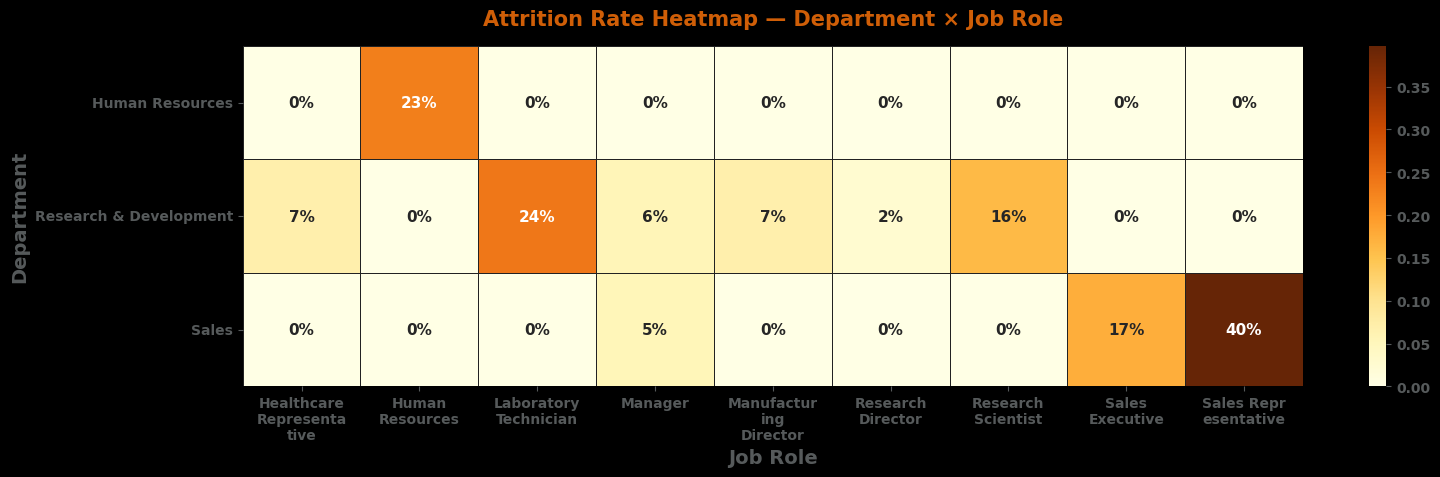


🔍 Top 5 Highest Risk Combinations:
                                              Attrition_Rate  Count
Department             JobRole                                     
Sales                  Sales Representative         0.397590     83
Research & Development Laboratory Technician        0.239382    259
Human Resources        Human Resources              0.230769     52
Sales                  Sales Executive              0.174847    326
Research & Development Research Scientist           0.160959    292


In [4]:
pivot = df.groupby(['Department','JobRole'])['Attrition'].mean().unstack().fillna(0)

plt.figure(figsize=(16, 5), facecolor='#000000')
ax = plt.gca(); ax.set_facecolor('#000000')

sns.heatmap(pivot, annot=True, fmt='.0%', cmap='YlOrBr',
            linewidths=0.5, linecolor='#222222',
            annot_kws={'size': 11, 'weight': 'bold'},
            ax=ax)

ax.set_title('Attrition Rate Heatmap — Department × Job Role',
             color=TITLE, fontweight='bold', fontsize=15, pad=15)
ax.set_xlabel('Job Role', color=LABEL, fontweight='bold')
ax.set_ylabel('Department', color=LABEL, fontweight='bold')
ax.tick_params(colors=VALUE)
plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0)
labels = [textwrap.fill(label.get_text(), width=10) for label in ax.get_xticklabels()]
ax.set_xticklabels(labels)
ax.set_ylabel(textwrap.fill(ax.get_ylabel(), width=10))
plt.tight_layout()
plt.show()




print("\n🔍 Top 5 Highest Risk Combinations:")
risk_combo = df.groupby(['Department','JobRole'])['Attrition'].agg(['mean','count'])
risk_combo.columns = ['Attrition_Rate','Count']
risk_combo = risk_combo[risk_combo['Count'] >= 5].sort_values('Attrition_Rate', ascending=False)
print(risk_combo.head(5).to_string())

In [23]:

print("\n📊 Survival Analysis Insights:")

# ── Fix: Median survival time using lifelines properly ──
kmf_ot  = KaplanMeierFitter()
kmf_not = KaplanMeierFitter()

kmf_ot.fit(df[df['OverTime']==1]['YearsAtCompany'],
           event_observed=df[df['OverTime']==1]['Attrition'],
           label='OverTime')

kmf_not.fit(df[df['OverTime']==0]['YearsAtCompany'],
            event_observed=df[df['OverTime']==0]['Attrition'],
            label='No OverTime')

median_ot  = kmf_ot.median_survival_time_
median_not = kmf_not.median_survival_time_

print(f"   Median survival — OverTime employees    : {median_ot} years")
print(f"   Median survival — No OverTime employees : {median_not} years")
print(f"   Log-rank p-value: {results_ot.p_value:.4f} — Significant difference ✅")
print(f"\n   📌 Interpretation:")
print(f"   OverTime employees are significantly more likely to leave earlier.")
print(f"   The log-rank test (p=0.0000) confirms this is NOT due to chance.")




📊 Survival Analysis Insights:
   Median survival — OverTime employees    : 24.0 years
   Median survival — No OverTime employees : 40.0 years
   Log-rank p-value: 0.0000 — Significant difference ✅

   📌 Interpretation:
   OverTime employees are significantly more likely to leave earlier.
   The log-rank test (p=0.0000) confirms this is NOT due to chance.


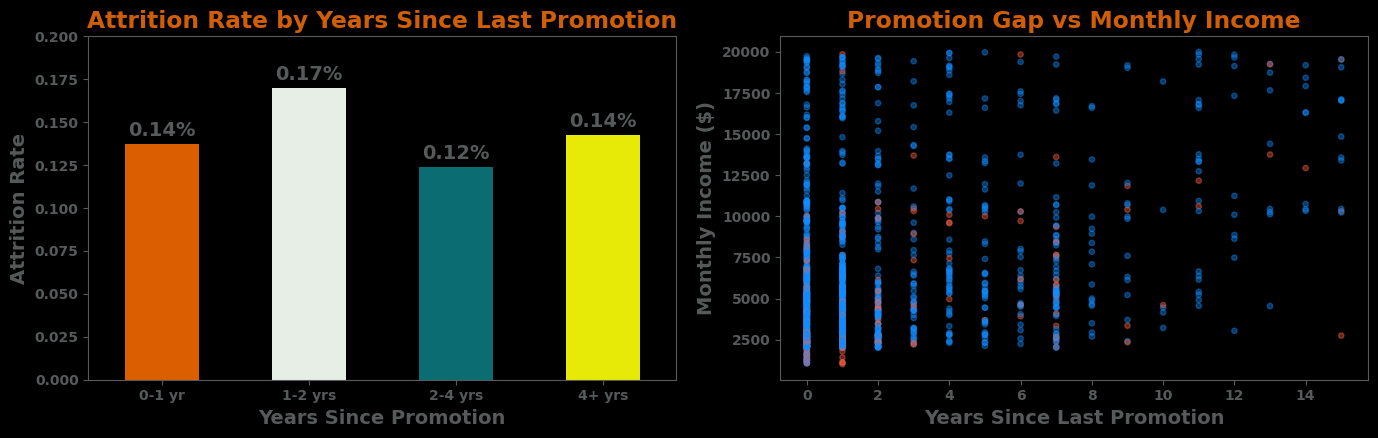


📊 Promotion Gap Insights:
   0-1 yr  : 13.7% attrition rate
   1-2 yrs : 17.0% attrition rate
   2-4 yrs : 12.4% attrition rate
   4+ yrs  : 14.2% attrition rate


In [6]:
# Promotion gap analysis
df['PromotionGap'] = df['YearsSinceLastPromotion']
promo_bins = pd.cut(df['YearsSinceLastPromotion'],
                    bins=[0,1,2,4,20],
                    labels=['0-1 yr','1-2 yrs','2-4 yrs','4+ yrs'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Attrition by Promotion Gap
promo_attr = df.groupby(promo_bins, observed=False)['Attrition'].mean()
promo_attr.plot(kind='bar', ax=axes[0], color=BAR, width=0.5)
axes[0].set_title('Attrition Rate by Years Since Last Promotion',
                   color=TITLE, fontweight='bold')
axes[0].set_xlabel('Years Since Promotion', color=LABEL)
axes[0].set_ylabel('Attrition Rate', color=LABEL)
axes[0].set_ylim(0,0.20)
axes[0].tick_params(axis='x', rotation=0)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f%%', padding=3, fontweight='bold', color=LABEL)

# Promotion Gap vs Income — scatter
scatter_colors = ['tomato' if a==1 else '#118DFF' for a in df['Attrition']]
axes[1].scatter(df['YearsSinceLastPromotion'], df['MonthlyIncome'],
                c=scatter_colors, alpha=0.4, s=15)
axes[1].set_title('Promotion Gap vs Monthly Income',
                   color=TITLE, fontweight='bold')
axes[1].set_xlabel('Years Since Last Promotion', color=LABEL)
axes[1].set_ylabel('Monthly Income ($)', color=LABEL)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n📊 Promotion Gap Insights:")
for label, rate in promo_attr.items():
    print(f"   {str(label).ljust(8)}: {rate*100:.1f}% attrition rate")

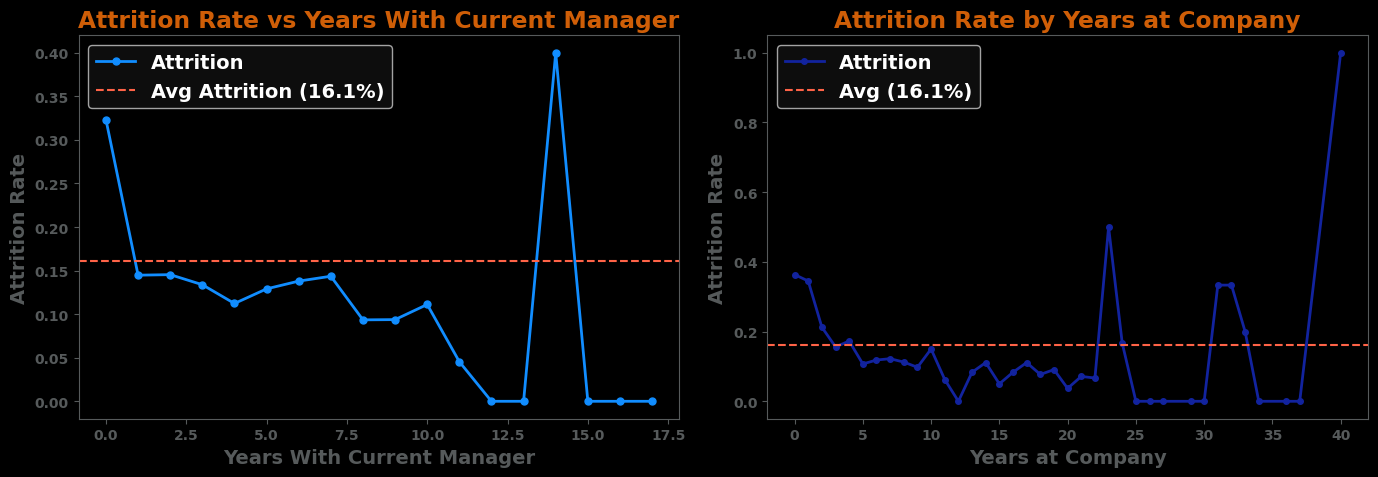


📊 Manager Impact Insights:
   Year 0 manager : 32.3% attrition
   Year 1 manager : 14.5% attrition
   Year 5+ manager: 11.2% attrition
   → Employees with 5+ years same manager churn 11.2% vs overall 16.1%


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Attrition vs Years with Manager
mgr_attr = df.groupby('YearsWithCurrManager')['Attrition'].mean()
mgr_attr.plot(kind='line', ax=axes[0], color='#118DFF', linewidth=2, marker='o', markersize=5)
axes[0].set_title('Attrition Rate vs Years With Current Manager',color=TITLE, fontweight='bold')
axes[0].set_xlabel('Years With Current Manager', color=LABEL)
axes[0].set_ylabel('Attrition Rate', color=LABEL)
axes[0].axhline(y=df['Attrition'].mean(), color='tomato', linestyle='--',linewidth=1.5, label=f"Avg Attrition ({df['Attrition'].mean()*100:.1f}%)")
axes[0].legend(facecolor='#111111', labelcolor='white')
axes[0].tick_params(colors=VALUE)

# Early tenure spike
tenure_attr = df.groupby('YearsAtCompany')['Attrition'].mean()
tenure_attr.plot(kind='line', ax=axes[1], color='#12239E', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Attrition Rate by Years at Company',color=TITLE, fontweight='bold')
axes[1].set_xlabel('Years at Company', color=LABEL)
axes[1].set_ylabel('Attrition Rate', color=LABEL)
axes[1].axhline(y=df['Attrition'].mean(), color='tomato', linestyle='--',linewidth=1.5, label=f"Avg ({df['Attrition'].mean()*100:.1f}%)")
axes[1].legend(facecolor='#111111', labelcolor='white')
axes[1].tick_params(colors=VALUE)

plt.tight_layout()
plt.show()

print("\n📊 Manager Impact Insights:")
print(f"   Year 0 manager : {df[df['YearsWithCurrManager']==0]['Attrition'].mean()*100:.1f}% attrition")
print(f"   Year 1 manager : {df[df['YearsWithCurrManager']==1]['Attrition'].mean()*100:.1f}% attrition")
print(f"   Year 5+ manager: {df[df['YearsWithCurrManager']>=5]['Attrition'].mean()*100:.1f}% attrition")
print(f"   → Employees with 5+ years same manager churn {df[df['YearsWithCurrManager']>=5]['Attrition'].mean()*100:.1f}% vs overall {df['Attrition'].mean()*100:.1f}%")

In [25]:
df_model = df.copy()

# Feature Engineering
df_model['IncomePerYear']     = (df_model['MonthlyIncome'] * 12).round(0)
df_model['TenureRatio']       = (df_model['YearsInCurrentRole'] / (df_model['YearsAtCompany'] + 1)).round(3)
df_model['IsNewEmployee']     = (df_model['YearsAtCompany'] <= 2).astype(int)
df_model['LowSatisfaction']   = (df_model['JobSatisfaction'] <= 2).astype(int)
df_model['PoorWorkLife']      = (df_model['WorkLifeBalance'] <= 2).astype(int)
df_model['PromotionGap']      = df_model['YearsSinceLastPromotion']
df_model['ManagerTenure']     = df_model['YearsWithCurrManager']
df_model['RiskScore']         = (
      df_model['OverTime'].astype(int)
    + df_model['LowSatisfaction']
    + df_model['PoorWorkLife']
    + df_model['IsNewEmployee']
    + (df_model['MonthlyIncome'] < 4000).astype(int)
    + (df_model['BusinessTravel'] == 'Travel_Frequently').astype(int)
    + (df_model['YearsSinceLastPromotion'] >= 4).astype(int)
)

# ✅ Separate target BEFORE encoding
y        = df_model['Attrition'].copy()
df_model = df_model.drop('Attrition', axis=1)

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])


X = df_model.copy()

print(f"✅ Features ready : {X.shape[1]} columns")
print(f"   Attrition Rate : {y.mean()*100:.1f}%")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"   Train: {X_train.shape} | Test: {X_test.shape}")

✅ Features ready : 39 columns
   Attrition Rate : 16.1%
   Train: (1176, 39) | Test: (294, 39)


Before SMOTE: Counter({0: 986, 1: 190})
After SMOTE : Counter({0: 986, 1: 986})


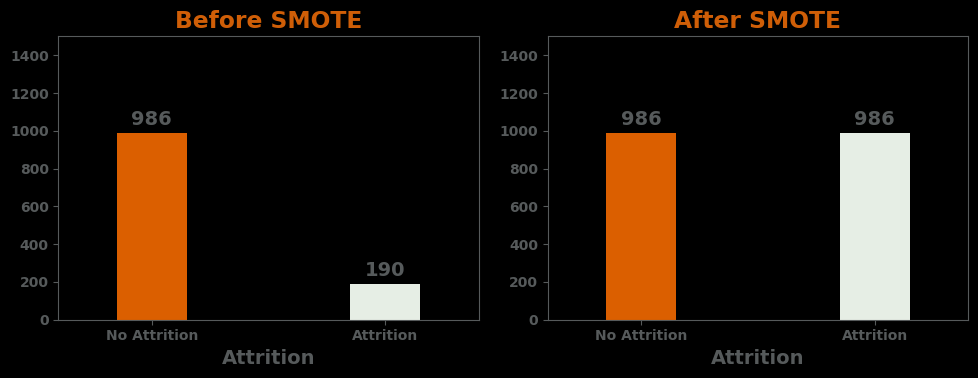

In [26]:
print("Before SMOTE:", Counter(y_train))
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("After SMOTE :", Counter(y_train_sm))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0], color=BAR, width=0.3)
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_xticklabels(['No Attrition','Attrition'], rotation=0)
axes[0].set_ylim(0, 1500)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.0f', padding=3, color=LABEL, fontweight='bold')

pd.Series(y_train_sm).value_counts().plot(kind='bar', ax=axes[1], color=BAR, width=0.3)
axes[1].set_title('After SMOTE', fontweight='bold')
axes[1].set_xticklabels(['No Attrition','Attrition'], rotation=0)
axes[1].set_ylim(0, 1500)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f', padding=3, color=LABEL, fontweight='bold')

plt.tight_layout()
plt.show()

In [27]:
pipelines = {
    'Logistic Regression': ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model',  LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model',  RandomForestClassifier(
            n_estimators=200, max_depth=10,
            class_weight='balanced', random_state=42))
    ]),
    'Gradient Boosting': ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model',  GradientBoostingClassifier(
            n_estimators=200, max_depth=5,
            learning_rate=0.05, subsample=0.8, random_state=42))
    ]),
    'XGBoost': ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model',  XGBClassifier(
            n_estimators=200, max_depth=5,
            learning_rate=0.05, subsample=0.8,
            eval_metric='logloss', random_state=42))
    ]),
}

results = {}
print(f"{'='*55}\n  MODEL COMPARISON\n{'='*55}")
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    results[name] = {'pipe': pipe, 'y_pred': y_pred, 'y_prob': y_prob, 'auc': auc}
    print(f"\n  {name} | AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['No Attrition','Attrition']))

best_name = max(results, key=lambda x: results[x]['auc'])
best_pipeline = results[best_name]['pipe']
print(f"\n🏆 Best Model: {best_name} | AUC: {results[best_name]['auc']:.4f}")

  MODEL COMPARISON

  Logistic Regression | AUC: 0.7586
              precision    recall  f1-score   support

No Attrition       0.89      0.86      0.88       247
   Attrition       0.38      0.45      0.41        47

    accuracy                           0.80       294
   macro avg       0.64      0.65      0.64       294
weighted avg       0.81      0.80      0.80       294


  Random Forest | AUC: 0.7449
              precision    recall  f1-score   support

No Attrition       0.88      0.91      0.89       247
   Attrition       0.39      0.32      0.35        47

    accuracy                           0.81       294
   macro avg       0.63      0.61      0.62       294
weighted avg       0.80      0.81      0.80       294


  Gradient Boosting | AUC: 0.7784
              precision    recall  f1-score   support

No Attrition       0.89      0.91      0.90       247
   Attrition       0.47      0.40      0.44        47

    accuracy                           0.83       294
   mac

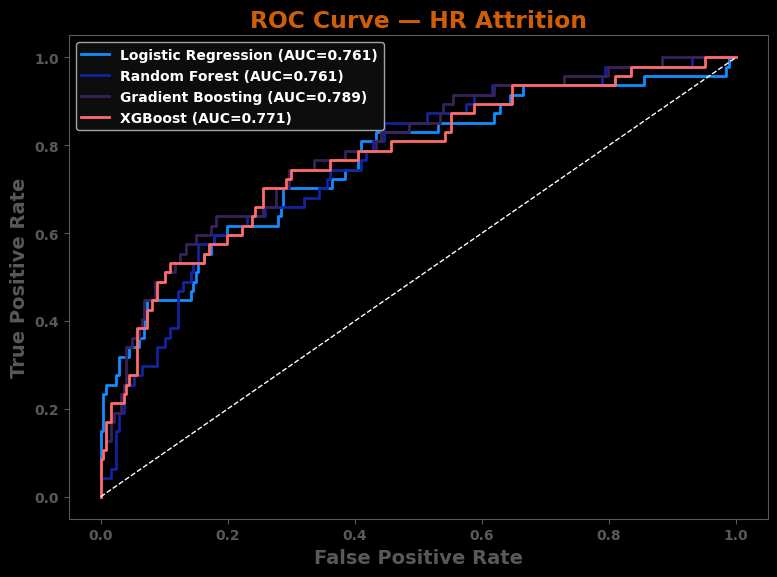

In [11]:
plt.figure(figsize=(8, 6), facecolor='#000000')
ax = plt.gca(); ax.set_facecolor('#000000')
colors_roc = ['#118DFF','#12239E','#382258','#FF6B6B']
for (name, r), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, color=color, label=f"{name} (AUC={r['auc']:.3f})", linewidth=2)
ax.plot([0,1],[0,1],'w--', linewidth=1)
ax.set_xlabel('False Positive Rate', color=LABEL, fontweight='bold')
ax.set_ylabel('True Positive Rate', color=LABEL, fontweight='bold')
ax.set_title('ROC Curve — HR Attrition', color=TITLE, fontweight='bold')
ax.legend(fontsize=10, facecolor='#111111', labelcolor='white')
plt.tight_layout(); plt.show()

In [12]:
xgb_pipe = ImbPipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model',  XGBClassifier(eval_metric='logloss', random_state=42))
])

param_dist = {
    'model__n_estimators':     [200, 300, 400],
    'model__max_depth':        [3, 5, 7],
    'model__learning_rate':    [0.01, 0.05, 0.1],
    'model__subsample':        [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 1.0],
    'model__min_child_weight': [1, 3, 5],
}

search = RandomizedSearchCV(
    xgb_pipe, param_dist,
    n_iter=25, cv=5, scoring='roc_auc',
    n_jobs=-1, random_state=42, verbose=1
)
search.fit(X_train, y_train)

y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
y_pred_tuned = search.best_estimator_.predict(X_test)
tuned_auc    = roc_auc_score(y_test, y_prob_tuned)

print(f"\n✅ Best Params : {search.best_params_}")
print(f"✅ Best CV AUC : {search.best_score_:.4f}")
print(f"✅ Test AUC    : {tuned_auc:.4f}")
print(classification_report(y_test, y_pred_tuned, target_names=['No Attrition','Attrition']))
best_pipeline = search.best_estimator_
print(f"\n🎯 Final Best AUC: {tuned_auc:.4f}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits

✅ Best Params : {'model__subsample': 0.8, 'model__n_estimators': 400, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}
✅ Best CV AUC : 0.7985
✅ Test AUC    : 0.7853
              precision    recall  f1-score   support

No Attrition       0.88      0.93      0.90       247
   Attrition       0.47      0.34      0.40        47

    accuracy                           0.83       294
   macro avg       0.68      0.63      0.65       294
weighted avg       0.82      0.83      0.82       294


🎯 Final Best AUC: 0.7853


Threshold Analysis:
 Threshold  F1_Attrition  Recall_Attrition  Precision_Attrition
      0.10         0.436             0.723                0.312
      0.15         0.467             0.681                0.356
      0.20         0.476             0.638                0.380
      0.25         0.500             0.617                0.420
      0.30         0.500             0.574                0.443
      0.35         0.480             0.511                0.453
      0.40         0.430             0.426                0.435
      0.45         0.434             0.383                0.500
      0.50         0.395             0.340                0.471
      0.55         0.416             0.340                0.533

✅ Best Threshold : 0.25

📊 Results at threshold 0.25:
              precision    recall  f1-score   support

No Attrition       0.92      0.84      0.88       247
   Attrition       0.42      0.62      0.50        47

    accuracy                           0.80       294
   

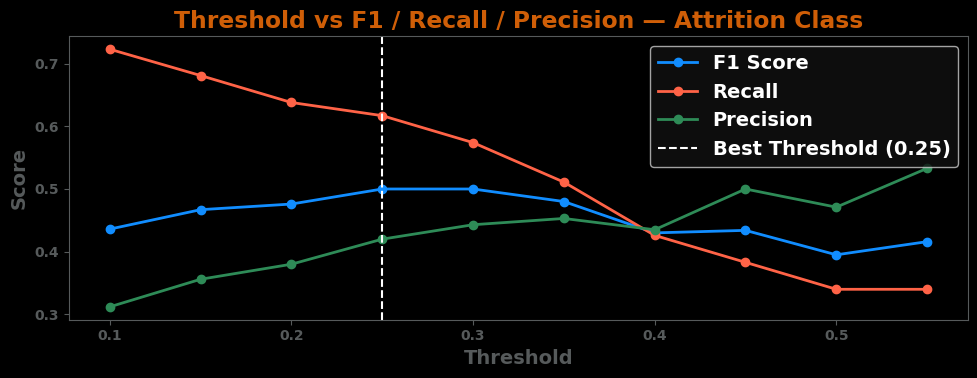


✅ BEST_THRESHOLD set to 0.25 — use this in prediction system


In [13]:
from sklearn.metrics import f1_score

thresholds    = np.arange(0.10, 0.60, 0.05)
results_thresh = []

for t in thresholds:
    preds  = (y_prob_tuned >= t).astype(int)
    f1     = f1_score(y_test, preds, pos_label=1)
    recall = (preds[y_test==1] == 1).mean()
    prec   = (y_test[preds==1] == 1).mean() if preds.sum() > 0 else 0
    results_thresh.append({
        'Threshold'        : round(t, 2),
        'F1_Attrition'     : round(f1, 3),
        'Recall_Attrition' : round(recall, 3),
        'Precision_Attrition': round(prec, 3)
    })

thresh_df   = pd.DataFrame(results_thresh)
best_thresh = thresh_df.loc[thresh_df['F1_Attrition'].idxmax(), 'Threshold']

print("Threshold Analysis:")
print(thresh_df.to_string(index=False))
print(f"\n✅ Best Threshold : {best_thresh}")

y_pred_best = (y_prob_tuned >= best_thresh).astype(int)
print(f"\n📊 Results at threshold {best_thresh}:")
print(classification_report(y_test, y_pred_best,
      target_names=['No Attrition','Attrition']))

# Visualize threshold vs recall/F1
plt.figure(figsize=(10, 4), facecolor='#000000')
ax = plt.gca(); ax.set_facecolor('#000000')
ax.plot(thresh_df['Threshold'], thresh_df['F1_Attrition'],
        'o-', color='#118DFF', linewidth=2, label='F1 Score')
ax.plot(thresh_df['Threshold'], thresh_df['Recall_Attrition'],
        'o-', color='tomato', linewidth=2, label='Recall')
ax.plot(thresh_df['Threshold'], thresh_df['Precision_Attrition'],
        'o-', color='seagreen', linewidth=2, label='Precision')
ax.axvline(x=best_thresh, color='white', linestyle='--',
           linewidth=1.5, label=f'Best Threshold ({best_thresh})')
ax.set_xlabel('Threshold', color=LABEL, fontweight='bold')
ax.set_ylabel('Score', color=LABEL, fontweight='bold')
ax.set_title('Threshold vs F1 / Recall / Precision — Attrition Class',
             color=TITLE, fontweight='bold')
ax.legend(facecolor='#111111', labelcolor='white')
ax.tick_params(colors=VALUE)
plt.tight_layout()
plt.show()

# Update best_pipeline threshold for prediction system
BEST_THRESHOLD = best_thresh
print(f"\n✅ BEST_THRESHOLD set to {BEST_THRESHOLD} — use this in prediction system")

✅ SHAP values computed


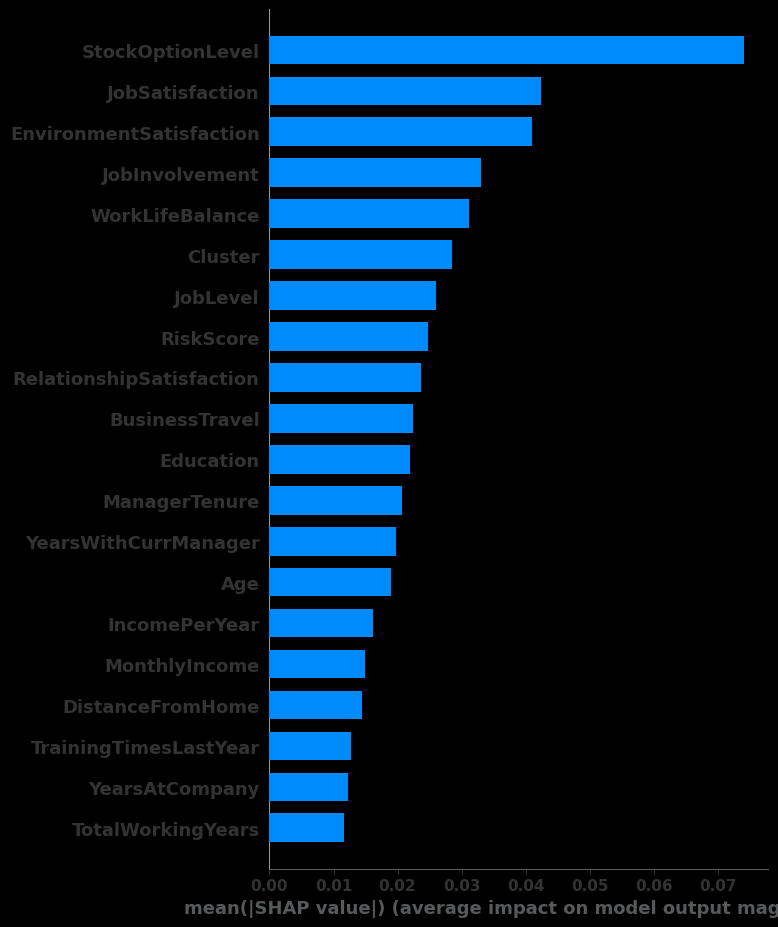

<Figure size 640x480 with 0 Axes>

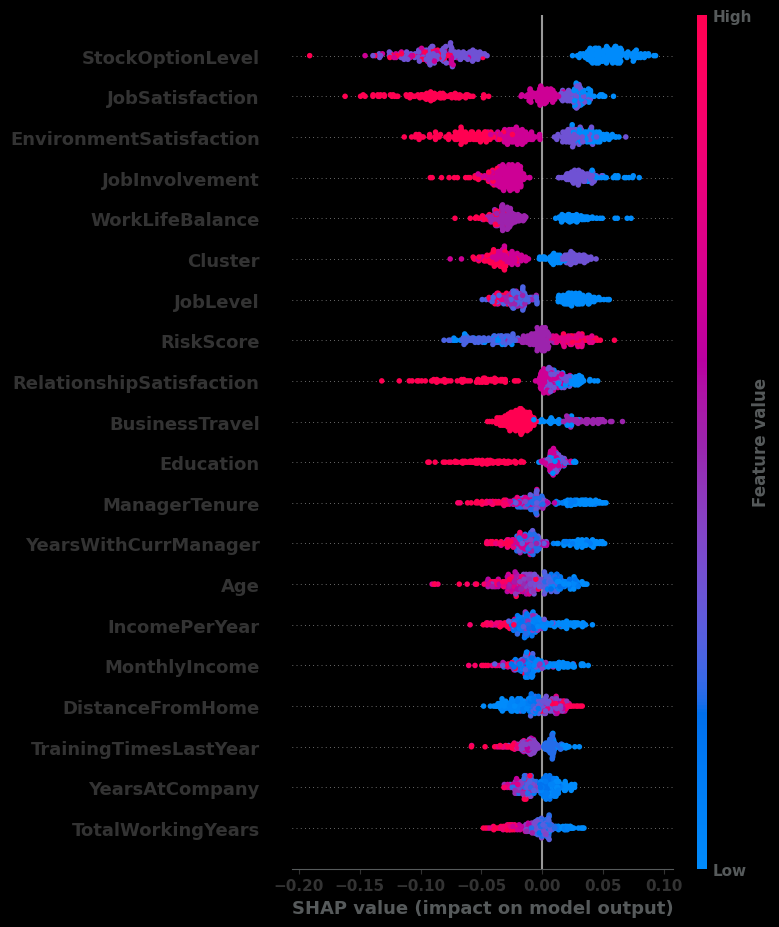

<Figure size 640x480 with 0 Axes>

<Figure size 3000x400 with 0 Axes>

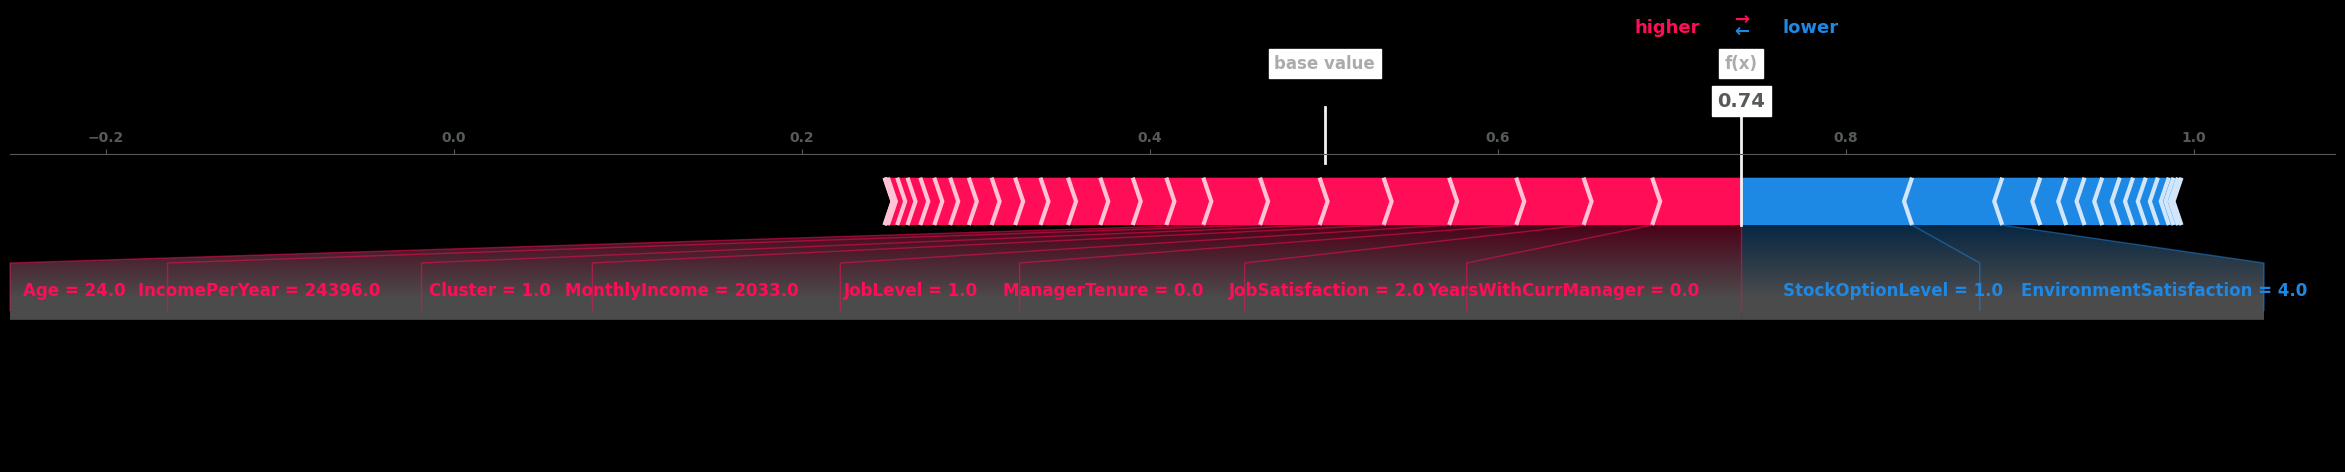

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [28]:
    scaler_shap = StandardScaler()
X_train_sc  = scaler_shap.fit_transform(X_train_sm)
X_test_sc   = scaler_shap.transform(X_test)

rf_shap = RandomForestClassifier(n_estimators=100, random_state=42)
rf_shap.fit(X_train_sc, y_train_sm)

explainer   = shap.TreeExplainer(rf_shap)
shap_values = explainer.shap_values(X_test_sc[:500])
print("✅ SHAP values computed")

shap.summary_plot(shap_values[:,:,1], X_test.iloc[:500],
                  feature_names=X.columns.tolist(),
                  plot_type='bar', show=True)


plt.tight_layout()
plt.show()

shap.summary_plot(shap_values[:,:,1], X_test.iloc[:500],
                  feature_names=X.columns.tolist(), show=True)
plt.tight_layout()
plt.show()

shap.initjs()
plt.figure(figsize=(30,4))
shap.force_plot(explainer.expected_value[1],
                shap_values[0,:,1],
                X_test.iloc[0],
                feature_names=X.columns.tolist(),figsize=(30,4),
                matplotlib=True)

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

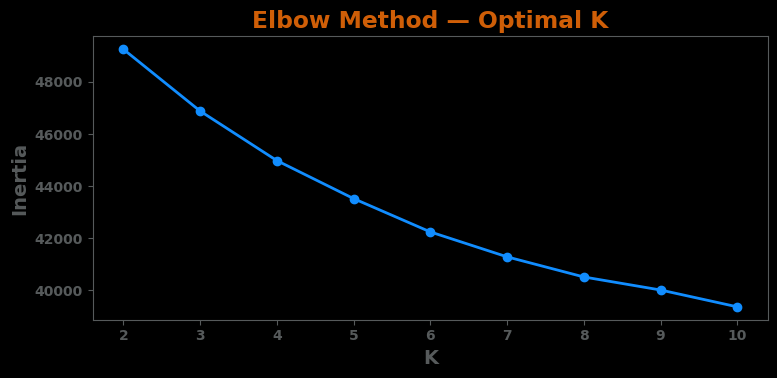

In [15]:
scaler_km = StandardScaler()
X_km      = scaler_km.fit_transform(X)

inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_km)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4), facecolor='#000000')
ax = plt.gca(); ax.set_facecolor('#000000')
ax.plot(range(2,11), inertias, 'o-', color='#118DFF', linewidth=2)
ax.set_xlabel('K', color=LABEL); ax.set_ylabel('Inertia', color=LABEL)
ax.set_title('Elbow Method — Optimal K', color=TITLE, fontweight='bold')
plt.tight_layout()
plt.show()



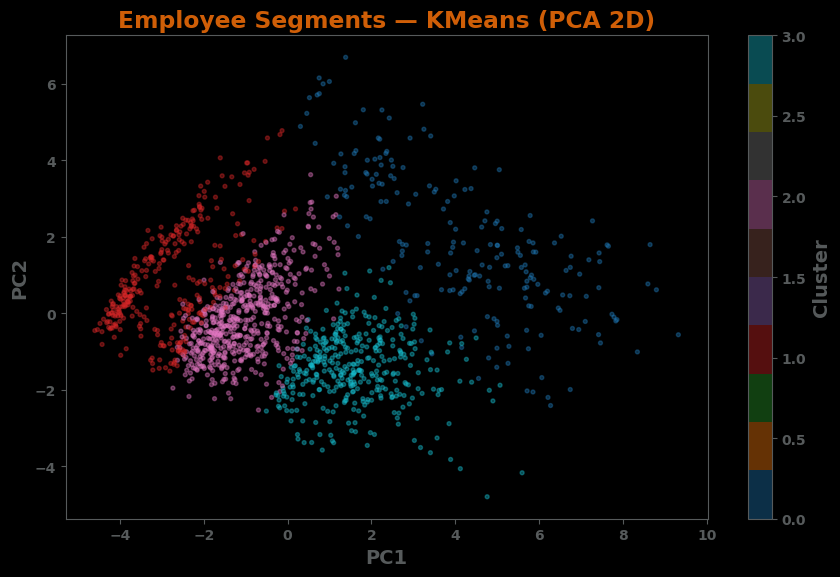


Cluster Attrition Rate:
Cluster
0    0.077
1    0.315
2    0.137
3    0.112
Name: Attrition, dtype: float64


In [16]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_km)

pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_km)

plt.figure(figsize=(9, 6), facecolor='#000000')
ax = plt.gca(); ax.set_facecolor('#000000')
scatter = ax.scatter(X_pca[:,0], X_pca[:,1],
                     c=df['Cluster'], cmap='tab10', alpha=0.4, s=8)
plt.colorbar(scatter, label='Cluster')
ax.set_title('Employee Segments — KMeans (PCA 2D)', color=TITLE, fontweight='bold')
ax.set_xlabel('PC1', color=LABEL); ax.set_ylabel('PC2', color=LABEL)
plt.tight_layout()
plt.show()

print("\nCluster Attrition Rate:")
print(df.groupby('Cluster')['Attrition'].mean().round(3))

  💰 COST OF ATTRITION CALCULATOR
  Employees Leaving              : 237
  Annual Salary at Risk          : $  13,614,492
  Estimated Replacement Cost     : $  20,421,738  (150% of salary)
  Cost per Departing Employee    : $      86,168
  Avg LTV — Leaving Employee     : $     459,079
  Avg LTV — Staying Employee     : $     775,836
  LTV Gap per Employee           : $     316,757
─────────────────────────────────────────────────────────────────
  If 30% retained → Cost Saved  : $   6,126,521
  If 50% retained → Cost Saved  : $  10,210,869

  📊 Replacement Cost by Department:
  Research & Development: $ 9,834,732 |██████████████████████████████
  Sales          : $ 9,784,404 |█████████████████████████████
  Human Resources: $   802,602 |██


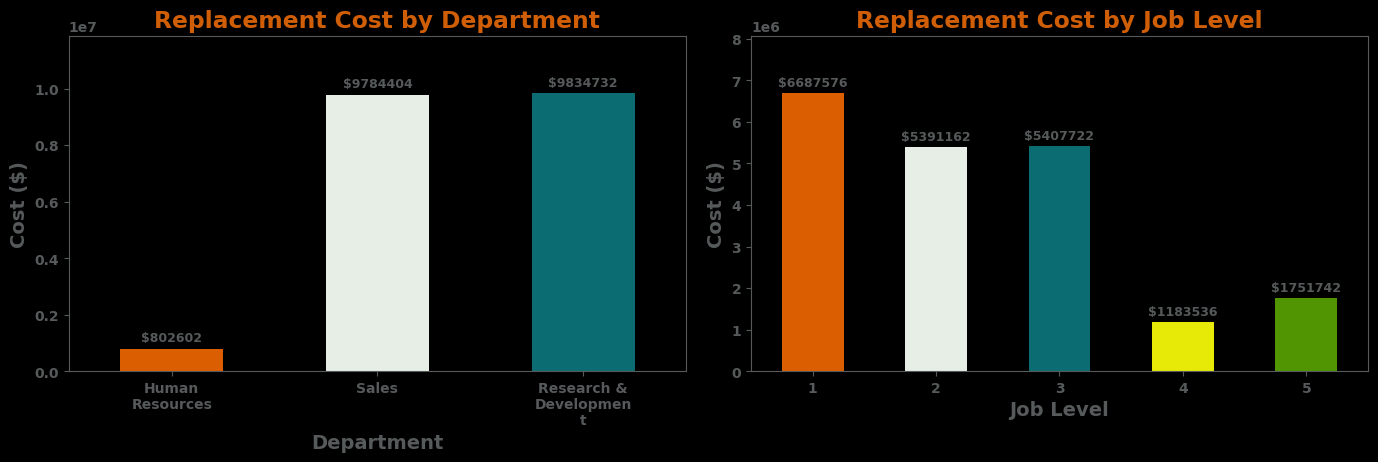

In [42]:
df['Attrition'] = y.values  # restore for analysis

leaving = df[df['Attrition'] == 1]
staying = df[df['Attrition'] == 0]

replacement_cost_pct = 1.5   # 150% of annual salary
annual_salaries      = leaving['MonthlyIncome'] * 12
total_annual_risk    = annual_salaries.sum()
total_replace_cost   = total_annual_risk * replacement_cost_pct
cost_per_employee    = total_replace_cost / len(leaving)
avg_ltv_leaving      = (leaving['MonthlyIncome'] * leaving['YearsAtCompany'] * 12).mean()
avg_ltv_staying      = (staying['MonthlyIncome'] * staying['YearsAtCompany'] * 12).mean()

print("=" * 65)
print("  💰 COST OF ATTRITION CALCULATOR")
print("=" * 65)
print(f"  Employees Leaving              : {len(leaving):,}")
print(f"  Annual Salary at Risk          : ${total_annual_risk:>12,.0f}")
print(f"  Estimated Replacement Cost     : ${total_replace_cost:>12,.0f}  (150% of salary)")
print(f"  Cost per Departing Employee    : ${cost_per_employee:>12,.0f}")
print(f"  Avg LTV — Leaving Employee     : ${avg_ltv_leaving:>12,.0f}")
print(f"  Avg LTV — Staying Employee     : ${avg_ltv_staying:>12,.0f}")
print(f"  LTV Gap per Employee           : ${avg_ltv_staying - avg_ltv_leaving:>12,.0f}")
print("─" * 65)
print(f"  If 30% retained → Cost Saved  : ${total_replace_cost * 0.30:>12,.0f}")
print(f"  If 50% retained → Cost Saved  : ${total_replace_cost * 0.50:>12,.0f}")
print("=" * 65)

# Cost breakdown by department
print("\n  📊 Replacement Cost by Department:")
dept_cost = (leaving.groupby('Department')['MonthlyIncome'].sum() * 12 * replacement_cost_pct)
for dept, cost in dept_cost.sort_values(ascending=False).items():
    bar = "█" * int(cost / dept_cost.max() * 30)
    print(f"  {str(dept).ljust(15)}: ${cost:>10,.0f} |{bar}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Subplot 1: Department ---
dept_cost.sort_values().plot(kind='bar', ax=axes[0], color=BAR)
axes[0].set_title('Replacement Cost by Department', color=TITLE, fontweight='bold')
axes[0].set_ylabel('Cost ($)', color=LABEL)
axes[0].set_xlabel('Department', color=LABEL)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='$%.0f', padding=3, color=LABEL, fontsize=9, fontweight='bold')

axes[0].set_xticklabels([textwrap.fill(l.get_text(), width=10) for l in axes[0].get_xticklabels()], rotation=0)
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.15)


# --- Subplot 2: Job Level ---
joblevel_cost.plot(kind='bar', ax=axes[1], color=BAR, width=0.5)
axes[1].set_title('Replacement Cost by Job Level', color=TITLE, fontweight='bold')
axes[1].set_xlabel('Job Level', color=LABEL , rotation = 0)
axes[1].set_ylabel('Cost ($)', color=LABEL )
axes[1].tick_params(axis='x', rotation=0)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='$%.0f', padding=3, color=LABEL, fontsize=9, fontweight='bold')

axes[1].set_ylim(0, axes[1].get_ylim()[1] * 1.15)

plt.tight_layout()
plt.show()

In [54]:
dept_map    = {d: i for i, d in enumerate(sorted(df['Department'].unique()))}
role_map    = {r: i for i, r in enumerate(sorted(df['JobRole'].unique()))}
travel_map  = {t: i for i, t in enumerate(sorted(df['BusinessTravel'].unique()))}
edu_map     = {e: i for i, e in enumerate(sorted(df['EducationField'].unique()))}
marital_map = {m: i for i, m in enumerate(sorted(df['MaritalStatus'].unique()))}

print("Department map :", dept_map)
print("JobRole map    :", role_map)
print("Travel map     :", travel_map)

def encode_employee(emp):
    tenure   = emp.get('YearsAtCompany', 0)
    role_yrs = emp.get('YearsInCurrentRole', 0)
    income   = emp.get('MonthlyIncome', 5000)
    overtime = 1 if emp.get('OverTime','No') == 'Yes' else 0
    job_sat  = emp.get('JobSatisfaction', 3)
    wlb      = emp.get('WorkLifeBalance', 3)
    travel   = emp.get('BusinessTravel','Travel_Rarely')
    promo    = emp.get('YearsSinceLastPromotion', 1)

    return {
        'Age':                     emp.get('Age', 30),
        'BusinessTravel':          travel_map.get(travel, 2),
        'DailyRate':               emp.get('DailyRate', 800),
        'Department':              dept_map.get(emp.get('Department','Sales'), 2),
        'DistanceFromHome':        emp.get('DistanceFromHome', 5),
        'Education':               emp.get('Education', 3),
        'EducationField':          edu_map.get(emp.get('EducationField','Other'), 4),
        'EnvironmentSatisfaction': emp.get('EnvironmentSatisfaction', 3),
        'Gender':                  1 if emp.get('Gender','Male')=='Male' else 0,
        'HourlyRate':              emp.get('HourlyRate', 65),
        'JobInvolvement':          emp.get('JobInvolvement', 3),
        'JobLevel':                emp.get('JobLevel', 2),
        'JobRole':                 role_map.get(emp.get('JobRole','Sales Executive'), 6),
        'JobSatisfaction':         job_sat,
        'MaritalStatus':           marital_map.get(emp.get('MaritalStatus','Single'), 2),
        'MonthlyIncome':           income,
        'MonthlyRate':             emp.get('MonthlyRate', 14000),
        'NumCompaniesWorked':      emp.get('NumCompaniesWorked', 1),
        'OverTime':                overtime,
        'PercentSalaryHike':       emp.get('PercentSalaryHike', 13),
        'PerformanceRating':       emp.get('PerformanceRating', 3),
        'RelationshipSatisfaction':emp.get('RelationshipSatisfaction', 3),
        'StockOptionLevel':        emp.get('StockOptionLevel', 0),
        'TotalWorkingYears':       emp.get('TotalWorkingYears', 8),
        'TrainingTimesLastYear':   emp.get('TrainingTimesLastYear', 3),
        'WorkLifeBalance':         wlb,
        'YearsAtCompany':          tenure,
        'YearsInCurrentRole':      role_yrs,
        'YearsSinceLastPromotion': promo,
        'YearsWithCurrManager':    emp.get('YearsWithCurrManager', 3),
        'IncomePerYear':           income * 12,
        'TenureRatio':             round(role_yrs / (tenure + 1), 3),
        'IsNewEmployee':           int(tenure <= 2),
        'LowSatisfaction':         int(job_sat <= 2),
        'PoorWorkLife':            int(wlb <= 2),
        'PromotionGap':            promo,
        'ManagerTenure':           emp.get('YearsWithCurrManager', 3),
        'RiskScore': (
              overtime + int(job_sat <= 2) + int(wlb <= 2)
            + int(tenure <= 2) + int(income < 4000)
            + int(travel == 'Travel_Frequently') + int(promo >= 4)
        ),
    }

def predict_employee(emp_dict, pipeline):
    try:
        input_df = pd.DataFrame([encoded]).reindex(columns=X.columns, fill_value=0)
        prob = pipeline.predict_proba(input_df)[0][1]
        pred = int(prob > 0.40)
        if prob > 0.7:   risk = "🔴 HIGH"
        elif prob > 0.3: risk = "🟡 MEDIUM"
        else:            risk = "🟢 LOW"
        return prob, pred, risk

    except Exception as e:
        print(f"Error during prediction: {e}")
        return 0.0, 0, "UNKNOWN"
        
def show_result(emp, prob, pred, risk):
    print("\n" + "="*55)
    print("  📊 ATTRITION PREDICTION RESULT")
    print("="*55)
    print(f"  Role            : {emp.get('JobRole','N/A')} | {emp.get('Department','N/A')}")
    print(f"  Attrition Prob  : {prob*100:.1f}%")
    print(f"  Prediction      : {'⚠️  WILL LEAVE' if pred else '✅  WILL STAY'}")
    print(f"  Risk Level      : {risk}")
    annual_salary = emp.get('MonthlyIncome', 0) * 12
    replace_cost  = annual_salary * 1.5
    print(f"  Annual Salary   : ${annual_salary:,.0f}")
    print(f"  Replacement Cost: ${replace_cost:,.0f}  (if leaves)")
    print("─"*55)
    print("  🔍 Risk Factors:")
    flags = []
    if emp.get('OverTime','No') == 'Yes':         flags.append("🔴 Working OverTime — burnout risk")
    if emp.get('JobSatisfaction', 4) <= 2:         flags.append("🔴 Low Job Satisfaction")
    if emp.get('WorkLifeBalance', 4) <= 2:         flags.append("🔴 Poor Work-Life Balance")
    if emp.get('YearsAtCompany', 5) <= 2:          flags.append("🔴 New Employee (≤2 yrs)")
    if emp.get('MonthlyIncome', 9999) < 4000:      flags.append("🔴 Below-Average Income")
    if emp.get('BusinessTravel') == 'Travel_Frequently': flags.append("🔴 Frequent Travel")
    if emp.get('YearsSinceLastPromotion', 0) >= 4: flags.append("🟡 No promotion in 4+ years")
    if emp.get('YearsWithCurrManager', 5) <= 1:    flags.append("🟡 New manager relationship")
    for f in flags: print(f"    {f}")
    if not flags: print("    ✅ No major risk factors")
    if pred:
        print("\n  💡 Retention Actions:")
        if emp.get('OverTime','No') == 'Yes':
            print("    • Reduce overtime — add headcount or redistribute")
        if emp.get('JobSatisfaction', 4) <= 2:
            print("    • 1:1 with manager — uncover specific concerns")
        if emp.get('MonthlyIncome', 9999) < 4000:
            print("    • Compensation review — benchmark against market")
        if emp.get('YearsAtCompany', 5) <= 2:
            print("    • Enrol in mentorship + structured onboarding")
        if emp.get('BusinessTravel') == 'Travel_Frequently':
            print("    • Reduce travel — offer remote flexibility")
        if emp.get('YearsSinceLastPromotion', 0) >= 4:
            print("    • Immediate career path discussion + promotion plan")
        est_save = replace_cost * 0.3
        print(f"\n  💰 If retained → saves ~${est_save:,.0f} in replacement costs")
    print("="*55)

print("✅ Prediction functions ready")
def get_validated(prompt, default, options):
    opt_map = {o.lower(): o for o in options}
    while True:
        val = input(f"{prompt} [{default}]: ").strip()
        val = val if val else default
        if val.lower() in opt_map: return opt_map[val.lower()]
        print(f"  ❌ Choose from: {', '.join(options)}")

def get_number(prompt, default, num_type=int):
    while True:
        val = input(f"{prompt} [{default}]: ").strip()
        val = val if val else str(default)
        try: return num_type(val)
        except: print("  ❌ Enter a valid number.")

def get_employee_input():
    print("\n" + "─"*45 + "\n  📋 ENTER EMPLOYEE DETAILS\n" + "─"*45)
    return {
        'Age':               get_number("Age", 30),
        'Gender':            get_validated("Gender", "Male", ["Male","Female"]),
        'MaritalStatus':     get_validated("Marital Status", "Single", ["Single","Married","Divorced"]),
        'Department':        get_validated("Department", "Sales",
                              ["Sales","Research & Development","Human Resources"]),
        'JobRole':           get_validated("Job Role", "Sales Executive",
                              ["Sales Executive","Research Scientist","Laboratory Technician",
                               "Manufacturing Director","Healthcare Representative","Manager",
                               "Sales Representative","Research Director","Human Resources"]),
        'Education':         get_number("Education Level (1-5)", 3),
        'EducationField':    get_validated("Education Field", "Other",
                              ["Life Sciences","Medical","Marketing",
                               "Technical Degree","Human Resources","Other"]),
        'MonthlyIncome':     get_number("Monthly Income ($)", 5000),
        'JobLevel':          get_number("Job Level (1-5)", 2),
        'YearsAtCompany':    get_number("Years at Company", 3),
        'YearsInCurrentRole':get_number("Years in Current Role", 2),
        'YearsSinceLastPromotion': get_number("Years Since Last Promotion", 1),
        'YearsWithCurrManager':    get_number("Years With Current Manager", 2),
        'TotalWorkingYears': get_number("Total Working Years", 8),
        'NumCompaniesWorked':get_number("Num Companies Worked", 2),
        'BusinessTravel':    get_validated("Business Travel", "Travel_Rarely",
                              ["Non-Travel","Travel_Rarely","Travel_Frequently"]),
        'OverTime':          get_validated("OverTime", "No", ["Yes","No"]),
        'JobSatisfaction':   get_number("Job Satisfaction (1-4)", 3),
        'WorkLifeBalance':   get_number("Work Life Balance (1-4)", 3),
        'EnvironmentSatisfaction': get_number("Environment Satisfaction (1-4)", 3),
        'JobInvolvement':    get_number("Job Involvement (1-4)", 3),
        'RelationshipSatisfaction': get_number("Relationship Satisfaction (1-4)", 3),
        'PerformanceRating': get_number("Performance Rating (1-4)", 3),
        'PercentSalaryHike': get_number("Percent Salary Hike", 13),
        'StockOptionLevel':  get_number("Stock Option Level (0-3)", 0),
        'TrainingTimesLastYear': get_number("Training Times Last Year", 3),
        'DistanceFromHome':  get_number("Distance From Home (km)", 5),
        'DailyRate':         get_number("Daily Rate", 800),
        'HourlyRate':        get_number("Hourly Rate", 65),
        'MonthlyRate':       get_number("Monthly Rate", 14000),
    }

# ── MAIN MENU ──
print("\n" + "="*50)
print("  🧑‍💼 HR ATTRITION PREDICTION SYSTEM")
print("="*50)

while True:
    print("\n1. Predict single employee")
    print("2. Predict batch of employees")
    print("3. Run example (3 employees)")
    print("4. Exit")
    choice = input("\nSelect option (1-4): ").strip()

    if choice == '1':
        emp = get_employee_input()
        prob, pred, risk = predict_employee(emp, best_pipeline)
        show_result(emp, prob, pred, risk)

    elif choice == '2':
        n_emp = get_number("How many employees to enter", 3)
        all_results = []
        for i in range(n_emp):
            print(f"\n── Employee {i+1} of {n_emp} ──")
            emp = get_employee_input()
            prob, pred, risk = predict_employee(emp, best_pipeline)
            show_result(emp, prob, pred, risk)
            all_results.append({
                'JobRole': emp.get('JobRole'), 'Department': emp.get('Department'),
                'Prob_%': f"{prob*100:.1f}%", 'Prediction': 'Leave' if pred else 'Stay',
                'Risk': risk, 'Replace_Cost': f"${emp.get('MonthlyIncome',0)*12*1.5:,.0f}"
            })
        print("\n📋 BATCH SUMMARY:")
        print(pd.DataFrame(all_results).to_string(index=False))

    elif choice == '3':
        examples = [
            {'Age':27,'Gender':'Male','MaritalStatus':'Single',
             'Department':'Sales','JobRole':'Sales Representative',
             'MonthlyIncome':2800,'JobLevel':1,'YearsAtCompany':1,
             'YearsInCurrentRole':1,'YearsSinceLastPromotion':0,
             'YearsWithCurrManager':1,'TotalWorkingYears':2,
             'NumCompaniesWorked':1,'BusinessTravel':'Travel_Frequently',
             'OverTime':'Yes','JobSatisfaction':1,'WorkLifeBalance':1,
             'EnvironmentSatisfaction':2,'JobInvolvement':2,
             'RelationshipSatisfaction':2,'PerformanceRating':3,
             'PercentSalaryHike':11,'StockOptionLevel':0,
             'TrainingTimesLastYear':2,'DistanceFromHome':25,
             'Education':3,'EducationField':'Marketing',
             'DailyRate':400,'HourlyRate':45,'MonthlyRate':10000},
            {'Age':45,'Gender':'Female','MaritalStatus':'Married',
             'Department':'Research & Development','JobRole':'Research Director',
             'MonthlyIncome':15000,'JobLevel':5,'YearsAtCompany':18,
             'YearsInCurrentRole':10,'YearsSinceLastPromotion':2,
             'YearsWithCurrManager':8,'TotalWorkingYears':22,
             'NumCompaniesWorked':2,'BusinessTravel':'Non-Travel',
             'OverTime':'No','JobSatisfaction':4,'WorkLifeBalance':4,
             'EnvironmentSatisfaction':4,'JobInvolvement':4,
             'RelationshipSatisfaction':4,'PerformanceRating':4,
             'PercentSalaryHike':22,'StockOptionLevel':3,
             'TrainingTimesLastYear':5,'DistanceFromHome':3,
             'Education':5,'EducationField':'Life Sciences',
             'DailyRate':1300,'HourlyRate':95,'MonthlyRate':20000},
            {'Age':34,'Gender':'Male','MaritalStatus':'Divorced',
             'Department':'Human Resources','JobRole':'Human Resources',
             'MonthlyIncome':4500,'JobLevel':2,'YearsAtCompany':4,
             'YearsInCurrentRole':2,'YearsSinceLastPromotion':4,
             'YearsWithCurrManager':1,'TotalWorkingYears':9,
             'NumCompaniesWorked':4,'BusinessTravel':'Travel_Rarely',
             'OverTime':'Yes','JobSatisfaction':2,'WorkLifeBalance':2,
             'EnvironmentSatisfaction':2,'JobInvolvement':2,
             'RelationshipSatisfaction':3,'PerformanceRating':3,
             'PercentSalaryHike':12,'StockOptionLevel':1,
             'TrainingTimesLastYear':2,'DistanceFromHome':18,
             'Education':3,'EducationField':'Human Resources',
             'DailyRate':700,'HourlyRate':58,'MonthlyRate':12000},
        ]
        for i, emp in enumerate(examples):
            print(f"\n── Example {i+1} ──")
            prob, pred, risk = predict_employee(emp, best_pipeline)
            show_result(emp, prob, pred, risk)

    elif choice == '4':
        print("\nExiting. Goodbye! 👋"); break
    else:
        print("Invalid — enter 1, 2, 3, or 4.")

Department map : {'Human Resources': 0, 'Research & Development': 1, 'Sales': 2}
JobRole map    : {'Healthcare Representative': 0, 'Human Resources': 1, 'Laboratory Technician': 2, 'Manager': 3, 'Manufacturing Director': 4, 'Research Director': 5, 'Research Scientist': 6, 'Sales Executive': 7, 'Sales Representative': 8}
Travel map     : {'Non-Travel': 0, 'Travel_Frequently': 1, 'Travel_Rarely': 2}
✅ Prediction functions ready

  🧑‍💼 HR ATTRITION PREDICTION SYSTEM

1. Predict single employee
2. Predict batch of employees
3. Run example (3 employees)
4. Exit



Select option (1-4):  3



── Example 1 ──
Error during prediction: name 'encoded' is not defined

  📊 ATTRITION PREDICTION RESULT
  Role            : Sales Representative | Sales
  Attrition Prob  : 0.0%
  Prediction      : ✅  WILL STAY
  Risk Level      : UNKNOWN
  Annual Salary   : $33,600
  Replacement Cost: $50,400  (if leaves)
───────────────────────────────────────────────────────
  🔍 Risk Factors:
    🔴 Working OverTime — burnout risk
    🔴 Low Job Satisfaction
    🔴 Poor Work-Life Balance
    🔴 New Employee (≤2 yrs)
    🔴 Below-Average Income
    🔴 Frequent Travel
    🟡 New manager relationship

── Example 2 ──
Error during prediction: name 'encoded' is not defined

  📊 ATTRITION PREDICTION RESULT
  Role            : Research Director | Research & Development
  Attrition Prob  : 0.0%
  Prediction      : ✅  WILL STAY
  Risk Level      : UNKNOWN
  Annual Salary   : $180,000
  Replacement Cost: $270,000  (if leaves)
───────────────────────────────────────────────────────
  🔍 Risk Factors:
    ✅ No major r


Select option (1-4):  4



Exiting. Goodbye! 👋
